In [1]:
using GraphMakie
using CSV
using DataFrames
using DelimitedFiles
using ColorSchemes
using Plots
using PlotThemes
using SankeyPlots

theme(:ggplot2)

In [2]:
complex_names = vec(readdlm("data/complex_names.txt", '\t', String, '\n'))
monomer_names = vec(readdlm("data/protein_names.txt", '\t', String, '\n'))
cofactor_names = vec(readdlm("data/cofactor_names.txt", '\t', String, '\n'))
element_names = vec(readdlm("data/element_ids.txt", '\t', String, '\n'))
pathway_names = vec(readdlm("data/pathway_names.txt", '\t', String, '\n'))

complex_ids = vec(readdlm("data/complex_ids.txt", '\t', String, '\n'))
monomer_ids = vec(readdlm("data/protein_ids.txt", '\t', String, '\n'))
cofactor_ids = vec(readdlm("data/cofactor_ids.txt", '\t', String, '\n'))
element_ids = vec(readdlm("data/element_ids.txt", '\t', String, '\n'))
pathway_ids = vec(readdlm("data/pathway_ids.txt", '\t', String, '\n'))





protein_names = [complex_names; monomer_names]
protein_ids = [complex_ids; monomer_ids]

C = Matrix(DataFrame(CSV.File("data/C_matrix.csv", header=false)))
P = Matrix(DataFrame(CSV.File("data/P_matrix.csv", header=false)))
E = Matrix(DataFrame(CSV.File("data/E_matrix.csv", header=false)))
W = Matrix(DataFrame(CSV.File("data/W_matrix.csv", header=false)))
W2 = Matrix(DataFrame(CSV.File("data/W2_matrix.csv", header=false)))
W1 = Matrix(DataFrame(CSV.File("data/W1_matrix.csv", header=false)))

Tree = Matrix(DataFrame(CSV.File("data/tree_matrix.csv")))


total_counts = Matrix(DataFrame(CSV.File("data/counts.csv", header=false)))

dismutase_idx = findfirst(isequal("SUPEROX-DISMUTFE-CPLX"), protein_ids)
total_counts[:, dismutase_idx] .= 15000

nadh_dehyd_idx =findfirst(isequal("NADH-DHI-CPLX"), protein_ids) 
total_counts[:, nadh_dehyd_idx, :] .= 800

counts = vec(total_counts[1, :])

# correction


5489-element Vector{Int64}:
   31
   86
 1049
 2617
  171
  485
  523
   59
 2036
   98
   47
  111
   18
    ⋮
    0
    1
    0
    1
  115
    9
   34
    0
    0
  522
    0
   39

In [22]:
findfirst(isequal("NADH-DHI-CPLX"), protein_ids)

928

In [32]:
C[928, findall(C[928, :] .!= 0)]

13-element Vector{Int64}:
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1

In [27]:
element_names

19-element Vector{String}:
 "N"
 "CU"
 "CA"
 "P"
 "NA"
 "K"
 "R"
 "SE"
 "MO"
 "S"
 "H"
 "ZN"
 "FE"
 "C"
 "MN"
 "CO"
 "MG"
 "NI"
 "O"

In [4]:
counts[4932]

366

In [5]:
cur_idx = findfirst(isequal("PYRUVATEDEH-CPLX"), protein_ids)
counts[cur_idx]

93

In [6]:
cur_idx = findfirst(isequal("EG10889-MONOMER"), protein_ids)
counts[cur_idx]

1823

In [7]:
cur_idx = findfirst(isequal("CPLX0-3962"), protein_ids)
counts[cur_idx]

3604

# Create Sankey diagram of where the iron flows in the cell.

In [8]:
cur_elements = ["FE"]
cap_entries = 25

# create counts matrices
C_P_counts = C .* repeat(counts, 1, length(monomer_names))
# C_E_counts = C_P_counts * P * E
C_O_counts = C_P_counts * P
cofactor_counts = vec(sum(C_O_counts, dims=1))
O_E_counts =  E .* repeat(cofactor_counts, 1, length(element_names))


# we have to normalize the array because C is not norm-preserving. 
C_norm = Array{Float64}(copy(C))

for i in 1:size(C)[2]
    C_norm[i, :] = C[i, :] / (sum(C[i, :]) + 0.00001)
end

C_P_norm_counts = C .* repeat(counts, 1, length(monomer_names))
C_W_norm_counts_cats = C_P_norm_counts * W * W2

# creating element indices of interest
element_idxs = [element in cur_elements for element in element_names]
element_idxs_nz = findall(vec(element_idxs))

# create cofactor indices of interest
cofactor_idxs = vec(E[:, element_idxs] .> 0)
cofactor_idxs_nz = findall(vec(cofactor_idxs))

## cplx sorted by counts of elements
capped_complex_idx = sortperm(vec(sum(C_O_counts[:, cofactor_idxs], dims=2)), rev=true)[1:cap_entries]
capped_classes = findall(vec(sum(C_W_norm_counts_cats[capped_complex_idx, :],dims=1) .!= 0))

capped_C_O = C_O_counts[capped_complex_idx, cofactor_idxs]
capped_C_W = C_W_norm_counts_cats[capped_complex_idx, capped_classes]
capped_O_E = O_E_counts[cofactor_idxs, element_idxs]


# corrective factor multiplies a cplx by its cofactor stoichiometry, needed for classes
corrective_factor = sum((C * P * E)[capped_complex_idx, element_idxs], dims=2)
cofactor_element_corrective_factor = vec(E[cofactor_idxs, element_idxs])
cplx_element_norm = vec(capped_C_O * vec(E[cofactor_idxs, element_idxs]))
cplx_class_norm = vec(sum(capped_C_W, dims=2))

# create "remaining cofactors"
total_cofactor_counts = vec(sum(C_O_counts[:, cofactor_idxs], dims=1))
in_use_cofactor_counts = vec(sum(capped_C_O, dims=1))
remaining_cofactor_counts = vec(total_cofactor_counts - in_use_cofactor_counts)

# create "no class cplx", just use C_O counts
unclassified_cplx_idxs = vec(sum(capped_C_W, dims=2) .== 0)
unclassified_cplx_counts = vec(capped_C_O * cofactor_element_corrective_factor)

# create sizes
n_cplx = length(capped_complex_idx)
n_classes = length(capped_classes)
n_cofactors = length(cofactor_idxs_nz)
n_elements = length(cur_elements)

# initialize arrays
src = Vector{Int64}()
dst = Vector{Int64}()
weights = Vector{Int64}()

# create labels
node_labels = [element_names[element_idxs]; 
                cofactor_names[cofactor_idxs];
                protein_names[capped_complex_idx]; 
                pathway_names[capped_classes];
                ["$c, other proteins" for c ∈ cofactor_names[cofactor_idxs]];
                "No pathway"
]

# create colors
colors = zeros(Int64, length(node_labels))

cofactor_colors = collect(1:(n_cofactors))
other_color = 0

colors[1] = 1
colors[2:(n_cofactors+1)] = cofactor_colors

# create sorting
## sorts elements
ordering_cofactors = Vector{Pair{Int64, Int64}}()
# sort_cofactors = sortperm(vec(sum(capped_C_O, dims=1)) .* cofactor_element_corrective_factor, rev=true)
# for i in 1:(n_cofactors-1)
#     push!(ordering_cofactors, (n_elements + sort_cofactors[i])=> (n_elements + sort_cofactors[i+1]))
# end


# order of index assignments
# elements, cplx, classes, remaining elements, no class label

# chart progress: E -> O -> C -> W
# E -> O 
for i in 1:n_elements
    for j in 1:n_cofactors
        if capped_O_E[j, i] != 0
            
            push!(src, i)
            push!(dst, n_elements + j)
            push!(weights, capped_O_E[j, i])
            
            # colors[n_elements + j] = colors[i]
            
        end  
    end
end

# E -> O, reverse order because im a dumbass
for i in 1:n_cofactors
    for j in 1:n_cplx
        if capped_C_O[j, i] != 0
            
            push!(src, n_elements + i)
            push!(dst, n_elements + n_cofactors + j)
            push!(weights, trunc(Int, capped_C_O[j, i] * cofactor_element_corrective_factor[i]))
            
            colors[n_elements + n_cofactors + j] = colors[n_elements + i]
            
        end  
    end
end

# # C -> W
for i in 1:n_cplx
    for j in 1:n_classes
        if capped_C_W[i, j] != 0
            
            # corrective factor multiplies by element multiplicity to maintain flow size
            
            push!(src, n_elements + n_cofactors + i)
            push!(dst, n_elements + n_cofactors  + n_cplx + j)
            push!(weights, trunc(Int64, trunc(Int, capped_C_W[i, j] * cplx_element_norm[i]/cplx_class_norm[i])))  # just corrects to sum of previous
            
            colors[n_elements + n_cofactors + n_cplx + j] = colors[n_elements + n_cofactors + i]
            
        end  
    end
    
#     if unclassified_cplx_idxs[i]
#         push!(src, n_elements + n_cofactors + i)
#         push!(dst, n_elements + n_cofactors + n_cplx + n_classes + n_elements + 1)
#         push!(weights, unclassified_cplx_counts[i])
        
#         colors[n_elements + n_cofactors + n_cplx + n_classes + n_elements + 1] = colors[n_elements + n_cofactors + i]
#     end
    
end

# O -> C remaining cnts
for i in 1:n_cofactors
    push!(src, n_elements + i)
    push!(dst, n_elements + n_cofactors + n_cplx + n_classes + i)
    push!(weights, trunc(Int, remaining_cofactor_counts[i] * cofactor_element_corrective_factor[i]))
    colors[n_elements + n_cofactors + n_cplx + n_classes + i] = colors[n_elements+i]
end 

# # C -> W remaining cplxes in 
for i in 1:n_cplx
    if unclassified_cplx_idxs[i]
        push!(src, n_elements + n_cofactors + i)
        push!(dst, n_elements + n_cofactors + n_cplx + n_classes + n_cofactors + 1)
        push!(weights, trunc(Int, unclassified_cplx_counts[i]))
        colors[n_elements + n_cofactors + n_cplx + n_classes + n_cofactors + 1] = colors[i]
    end
end 




In [9]:
sankey(src, dst, weights, 
        compact = true,
        node_labels = node_labels,
        node_colors = cgrad(:copper, maximum(colors)+3, categorical = true, rev=true)[2:(maximum(colors)+2)][colors],
        edge_color = :src,
        size=(1800, 1000),
        label_position = :right,
        label_size = 12,
        force_order = ordering_cofactors,
        title="How does the cell distribute it's precious iron across proteins where iron is part of a cofactor?"
)

savefig("figures/iron.svg")

"/Users/cyrus/vivarium-ecoli/notebooks/cofactors/figures/iron.svg"

# with fine grained pathways

# Redoing the plotting prep 

In [10]:
cur_elements = ["ZN"]
cap_entries = 15

# create counts matrices
C_P_counts = C .* repeat(counts, 1, length(monomer_names))
C_E_counts = C_P_counts * P * E


# we have to normalize the array because C is not norm-preserving. 
C_W = C * W * W2
C_W_norm = Array{Float64}(copy(C_W))

for i in 1:size(C_W_norm)[1]
    C_W_norm[i, :] = C_W[i, :] / (sum(C_W[i, :]) + 0.00001)
end

C_W_norm_counts_cats = C_W_norm

# creating element indices of interest
element_idxs = [element in cur_elements for element in element_names]
element_idxs_nz = findall(vec(element_idxs))

## cplx sorted by counts of elements
capped_complex_idx = sortperm(vec(sum(C_E_counts[:, element_idxs], dims=2)), rev=true)[1:cap_entries]
capped_classes = findall(vec(sum(C_W_norm_counts_cats[capped_complex_idx, :],dims=1) .!= 0))

capped_C_E = C_E_counts[capped_complex_idx, element_idxs]
capped_C_W = C_W_norm_counts_cats[capped_complex_idx, capped_classes]


# corrective factor multiplies a cplx by its cofactor stoichiometry
corrective_factor = sum((C * P * E)[capped_complex_idx, element_idxs], dims=2)

# create "remaining elements"
total_element_counts = vec(sum(C_E_counts[:, element_idxs], dims=1))
in_use_element_counts = vec(sum(capped_C_E, dims=1))
remaining_element_counts = vec(total_element_counts - in_use_element_counts)

# create "no class cplx", just use C_E counts
unclassified_cplx_idxs = vec(sum(capped_C_W, dims=2) .== 0)
unclassified_cplx_counts = vec(sum(capped_C_E, dims=2))

# create sizes
n_cplx = length(capped_complex_idx)
n_classes = length(capped_classes)
n_elements = length(cur_elements)

# initialize arrays
src = Vector{Int64}()
dst = Vector{Int64}()
weights = Vector{Int64}()

# create labels
node_labels = [element_names[element_idxs]; 
                protein_names[capped_complex_idx]; 
                pathway_names[capped_classes];
                ["Remaining $c proteins" for c ∈ element_names[element_idxs]];
                "No pathway"]

# create colors
colors = zeros(Int64, length(node_labels))

element_colors = collect(1:(n_elements))
other_color = 0

colors[1:n_elements] = element_colors

# create sorting
## sorts elements
ordering_elements = Vector{Pair{Int64, Int64}}()
sort_elements = sortperm(vec(sum(capped_C_E, dims=1)), rev=true)
for i in 1:(n_elements-1)
    push!(ordering_elements, sort_elements[i]=>sort_elements[i+1])
end

# sort_cplxs = sortperm(vec(sum(capped_C_E, dims=2)), rev=true)
# for i in 1:(n_cplx-1)
#     push!(ordering_elements, n_elements+sort_cplxs[i]=>n_elements+sort_cplxs[i+1]) 
# end

# order of index assignments
# elements, cplx, classes, remaining elements, no class label

# chart progress: E -> C -> W
# E -> C, reverse order because im a dumbass
for i in 1:n_elements
    for j in 1:n_cplx
        if capped_C_E[j, i] != 0
            
            push!(src, i)
            push!(dst, n_elements + j)
            push!(weights, capped_C_E[j, i])
            
            colors[n_elements + j] = colors[i]
            
        end  
    end
end

# # C -> W
for i in 1:n_cplx
    for j in 1:n_classes
        if capped_C_W[i, j] != 0
            
            # corrective factor multiplies by element multiplicity to maintain flow size
            
            push!(src, n_elements + i)
            push!(dst, n_elements + n_cplx + j)
            push!(weights, trunc(Int64, capped_C_W[i, j] * capped_C_E[i]))   
            
            colors[n_elements + n_cplx + j] = colors[n_elements + i]
            
        end  
    end
    
    if unclassified_cplx_idxs[i]
        push!(src, n_elements + i)
        push!(dst, n_elements + n_cplx + n_classes + n_elements + 1)
        push!(weights, unclassified_cplx_counts[i])
        
        colors[n_elements + n_cplx + n_classes + n_elements + 1] = colors[n_elements + i]
    end
    
end

# E -> C remaining cnts
for i in 1:n_elements
    push!(src, i)
    push!(dst, n_elements + n_cplx + n_classes + i)
    push!(weights, remaining_element_counts[i])
    colors[n_elements + n_cplx + n_classes + i] = colors[i]
end 

# # C -> P remaining cnts in displayed classes
# for i in 1:n_elements



In [11]:
sankey(src, dst, weights, 
        compact = true,
        node_labels = node_labels,
        node_colors = cgrad(:copper, maximum(colors)+1, categorical = true, rev=true)[colors],
        edge_color = :src,
        size=(1800, 1000),
        label_position = :right,
        label_size = 12,
        force_order = ordering_cofactors,
        title="How does the cell distribute its zinc across proteins where iron is part of a cofactor?"
)

savefig("figures/zinc.svg")

"/Users/cyrus/vivarium-ecoli/notebooks/cofactors/figures/zinc.svg"

# Manganese

In [12]:
cur_elements = ["MN"]
cap_entries = 10

# create counts matrices
C_P_counts = C .* repeat(counts, 1, length(monomer_names))
C_E_counts = C_P_counts * P * E


# we have to normalize the array because C is not norm-preserving. 
C_W = C * W * W2
C_W_norm = Array{Float64}(copy(C_W))

for i in 1:size(C_W_norm)[1]
    C_W_norm[i, :] = C_W[i, :] / (sum(C_W[i, :]) + 0.00001)
end

C_W_norm_counts_cats = C_W_norm

# creating element indices of interest
element_idxs = [element in cur_elements for element in element_names]
element_idxs_nz = findall(vec(element_idxs))

## cplx sorted by counts of elements
capped_complex_idx = sortperm(vec(sum(C_E_counts[:, element_idxs], dims=2)), rev=true)[1:cap_entries]
capped_classes = findall(vec(sum(C_W_norm_counts_cats[capped_complex_idx, :],dims=1) .!= 0))

capped_C_E = C_E_counts[capped_complex_idx, element_idxs]
capped_C_W = C_W_norm_counts_cats[capped_complex_idx, capped_classes]


# corrective factor multiplies a cplx by its cofactor stoichiometry
corrective_factor = sum((C * P * E)[capped_complex_idx, element_idxs], dims=2)

# create "remaining elements"
total_element_counts = vec(sum(C_E_counts[:, element_idxs], dims=1))
in_use_element_counts = vec(sum(capped_C_E, dims=1))
remaining_element_counts = vec(total_element_counts - in_use_element_counts)

# create "no class cplx", just use C_E counts
unclassified_cplx_idxs = vec(sum(capped_C_W, dims=2) .== 0)
unclassified_cplx_counts = vec(sum(capped_C_E, dims=2))

# create sizes
n_cplx = length(capped_complex_idx)
n_classes = length(capped_classes)
n_elements = length(cur_elements)

# initialize arrays
src = Vector{Int64}()
dst = Vector{Int64}()
weights = Vector{Int64}()

# create labels
node_labels = [element_names[element_idxs]; 
                protein_names[capped_complex_idx]; 
                pathway_names[capped_classes];
                ["Remaining $c proteins" for c ∈ element_names[element_idxs]];
                "No pathway"]

# create colors
colors = zeros(Int64, length(node_labels))

element_colors = collect(1:(n_elements))
other_color = 0

colors[1:n_elements] = element_colors

# create sorting
## sorts elements
ordering_elements = Vector{Pair{Int64, Int64}}()
sort_elements = sortperm(vec(sum(capped_C_E, dims=1)), rev=true)
for i in 1:(n_elements-1)
    push!(ordering_elements, sort_elements[i]=>sort_elements[i+1])
end

# sort_cplxs = sortperm(vec(sum(capped_C_E, dims=2)), rev=true)
# for i in 1:(n_cplx-1)
#     push!(ordering_elements, n_elements+sort_cplxs[i]=>n_elements+sort_cplxs[i+1]) 
# end

# order of index assignments
# elements, cplx, classes, remaining elements, no class label

# chart progress: E -> C -> W
# E -> C, reverse order because im a dumbass
for i in 1:n_elements
    for j in 1:n_cplx
        if capped_C_E[j, i] != 0
            
            push!(src, i)
            push!(dst, n_elements + j)
            push!(weights, capped_C_E[j, i])
            
            colors[n_elements + j] = colors[i]
            
        end  
    end
end

# # C -> W
for i in 1:n_cplx
    for j in 1:n_classes
        if capped_C_W[i, j] != 0
            
            # corrective factor multiplies by element multiplicity to maintain flow size
            
            push!(src, n_elements + i)
            push!(dst, n_elements + n_cplx + j)
            push!(weights, trunc(Int64, capped_C_W[i, j] * capped_C_E[i]))   
            
            colors[n_elements + n_cplx + j] = colors[n_elements + i]
            
        end  
    end
    
    if unclassified_cplx_idxs[i]
        push!(src, n_elements + i)
        push!(dst, n_elements + n_cplx + n_classes + n_elements + 1)
        push!(weights, unclassified_cplx_counts[i])
        
        colors[n_elements + n_cplx + n_classes + n_elements + 1] = colors[n_elements + i]
    end
    
end

# E -> C remaining cnts
for i in 1:n_elements
    push!(src, i)
    push!(dst, n_elements + n_cplx + n_classes + i)
    push!(weights, remaining_element_counts[i])
    colors[n_elements + n_cplx + n_classes + i] = colors[i]
end 

# # C -> P remaining cnts in displayed classes
# for i in 1:n_elements



In [13]:
sankey(src, dst, weights, 
        compact = true,
        node_labels = node_labels,
        node_colors = cgrad(:copper, maximum(colors)+1, categorical = true, rev=true)[colors],
        edge_color = :src,
        size=(1800, 1000),
        label_position = :right,
        label_size = 12,
        force_order = ordering_cofactors,
        title="How does the cell distribute its manganese across proteins where iron is part of a cofactor?"
)

savefig("figures/manganese.svg")

"/Users/cyrus/vivarium-ecoli/notebooks/cofactors/figures/manganese.svg"

In [14]:
cur_elements = ["CA", "CU", "MO", "SE"]
cap_entries = 20

# create counts matrices
C_P_counts = C .* repeat(counts, 1, length(monomer_names))
C_E_counts = C_P_counts * P * E


# we have to normalize the array because C is not norm-preserving. 
C_W = C * W * W2
C_W_norm = Array{Float64}(copy(C_W))

for i in 1:size(C_W_norm)[1]
    C_W_norm[i, :] = C_W[i, :] / (sum(C_W[i, :]) + 0.00001)
end

C_W_norm_counts_cats = C_W_norm

# creating element indices of interest
element_idxs = [element in cur_elements for element in element_names]
element_idxs_nz = findall(vec(element_idxs))

## cplx sorted by counts of elements
capped_complex_idx = sortperm(vec(sum(C_E_counts[:, element_idxs], dims=2)), rev=true)[1:cap_entries]
capped_classes = findall(vec(sum(C_W_norm_counts_cats[capped_complex_idx, :],dims=1) .!= 0))

capped_C_E = C_E_counts[capped_complex_idx, element_idxs]
capped_C_W = C_W_norm_counts_cats[capped_complex_idx, capped_classes]


# corrective factor multiplies a cplx by its cofactor stoichiometry
corrective_factor = sum((C * P * E)[capped_complex_idx, element_idxs], dims=2)

# create "remaining elements"
total_element_counts = vec(sum(C_E_counts[:, element_idxs], dims=1))
in_use_element_counts = vec(sum(capped_C_E, dims=1))
remaining_element_counts = vec(total_element_counts - in_use_element_counts)

# create "no class cplx", just use C_E counts
unclassified_cplx_idxs = vec(sum(capped_C_W, dims=2) .== 0)
unclassified_cplx_counts = vec(sum(capped_C_E, dims=2))

# create sizes
n_cplx = length(capped_complex_idx)
n_classes = length(capped_classes)
n_elements = length(cur_elements)

# initialize arrays
src = Vector{Int64}()
dst = Vector{Int64}()
weights = Vector{Int64}()

# create labels
node_labels = [element_names[element_idxs]; 
                protein_names[capped_complex_idx]; 
                pathway_names[capped_classes];
                ["Remaining $c proteins" for c ∈ element_names[element_idxs]];
                "No pathway"]

# create colors
colors = zeros(Int64, length(node_labels))

element_colors = collect(1:(n_elements))
other_color = 0

colors[1:n_elements] = element_colors

# create sorting
## sorts elements
ordering_elements = Vector{Pair{Int64, Int64}}()
sort_elements = sortperm(vec(sum(capped_C_E, dims=1)), rev=true)
for i in 1:(n_elements-1)
    push!(ordering_elements, sort_elements[i]=>sort_elements[i+1])
end

# sort_cplxs = sortperm(vec(sum(capped_C_E, dims=2)), rev=true)
# for i in 1:(n_cplx-1)
#     push!(ordering_elements, n_elements+sort_cplxs[i]=>n_elements+sort_cplxs[i+1]) 
# end

# order of index assignments
# elements, cplx, classes, remaining elements, no class label

# chart progress: E -> C -> W
# E -> C, reverse order because im a dumbass
for i in 1:n_elements
    for j in 1:n_cplx
        if capped_C_E[j, i] != 0
            
            push!(src, i)
            push!(dst, n_elements + j)
            push!(weights, capped_C_E[j, i])
            
            colors[n_elements + j] = colors[i]
            
        end  
    end
end

# # C -> W
for i in 1:n_cplx
    for j in 1:n_classes
        if capped_C_W[i, j] != 0
            
            # corrective factor multiplies by element multiplicity to maintain flow size
            
            push!(src, n_elements + i)
            push!(dst, n_elements + n_cplx + j)
            push!(weights, trunc(Int64, capped_C_W[i, j] * vec(sum(capped_C_E, dims=2))[i]))   
            
            colors[n_elements + n_cplx + j] = colors[n_elements + i]
            
        end  
    end
    
    if unclassified_cplx_idxs[i]
        push!(src, n_elements + i)
        push!(dst, n_elements + n_cplx + n_classes + n_elements + 1)
        push!(weights, unclassified_cplx_counts[i])
        
        colors[n_elements + n_cplx + n_classes + n_elements + 1] = colors[n_elements + i]
    end
    
end

# E -> C remaining cnts
for i in 1:n_elements
    push!(src, i)
    push!(dst, n_elements + n_cplx + n_classes + i)
    push!(weights, remaining_element_counts[i])
    colors[n_elements + n_cplx + n_classes + i] = colors[i]
end 

# # C -> P remaining cnts in displayed classes
# for i in 1:n_elements



In [15]:
sankey(src, dst, weights, 
        compact = true,
        node_labels = node_labels,
        node_colors = cgrad(:copper, maximum(colors)+1, categorical = true, rev=true)[colors],
        edge_color = :src,
        size=(1800, 1000),
        label_position = :right,
        label_size = 12,
        force_order = ordering_cofactors,
        title="Rarely used, yet important  metals: calcium, copper, molybdenum and selenium"
)

savefig("figures/other_metals.svg")

"/Users/cyrus/vivarium-ecoli/notebooks/cofactors/figures/other_metals.svg"

# organic cofactors

In [16]:
cur_elements = ["FAD", "FMN", "thiamine diphosphate", "pyridoxal 5'-phosphate", "biotin", "(<i>R</i>)-lipoate"]
cap_entries = 20

# create counts matrices
C_P_counts = C .* repeat(counts, 1, length(monomer_names))
C_E_counts = C_P_counts * P #  * E


# we have to normalize the array because C is not norm-preserving. 
C_W = C * W * W2
C_W_norm = Array{Float64}(copy(C_W))

for i in 1:size(C_W_norm)[1]
    C_W_norm[i, :] = C_W[i, :] / (sum(C_W[i, :]) + 0.00001)
end

C_W_norm_counts_cats = C_W_norm

# creating element indices of interest
element_idxs = [element in cur_elements for element in cofactor_names]
element_idxs_nz = findall(vec(element_idxs))

## cplx sorted by counts of elements
capped_complex_idx = sortperm(vec(sum(C_E_counts[:, element_idxs], dims=2)), rev=true)[1:cap_entries]
capped_classes = findall(vec(sum(C_W_norm_counts_cats[capped_complex_idx, :],dims=1) .!= 0))

capped_C_E = C_E_counts[capped_complex_idx, element_idxs]
capped_C_W = C_W_norm_counts_cats[capped_complex_idx, capped_classes]


# corrective factor multiplies a cplx by its cofactor stoichiometry
corrective_factor = sum((C * P)[capped_complex_idx, element_idxs], dims=2)

# create "remaining elements"
total_element_counts = vec(sum(C_E_counts[:, element_idxs], dims=1))
in_use_element_counts = vec(sum(capped_C_E, dims=1))
remaining_element_counts = vec(total_element_counts - in_use_element_counts)

# create "no class cplx", just use C_E counts
unclassified_cplx_idxs = vec(sum(capped_C_W, dims=2) .== 0)
unclassified_cplx_counts = vec(sum(capped_C_E, dims=2))

# create sizes
n_cplx = length(capped_complex_idx)
n_classes = length(capped_classes)
n_elements = length(cur_elements)

# initialize arrays
src = Vector{Int64}()
dst = Vector{Int64}()
weights = Vector{Int64}()

# create labels
node_labels = [cofactor_names[element_idxs]; 
                protein_names[capped_complex_idx]; 
                pathway_names[capped_classes];
                ["Remaining $c proteins" for c ∈ cofactor_names[element_idxs]];
                "No pathway"]

# create colors
colors = zeros(Int64, length(node_labels))

element_colors = collect(1:(n_elements))
other_color = 0

colors[1:n_elements] = element_colors

# create sorting
## sorts elements
ordering_elements = Vector{Pair{Int64, Int64}}()
sort_elements = sortperm(vec(sum(capped_C_E, dims=1)), rev=true)
for i in 1:(n_elements-1)
    push!(ordering_elements, sort_elements[i]=>sort_elements[i+1])
end

# sort_cplxs = sortperm(vec(sum(capped_C_E, dims=2)), rev=true)
# for i in 1:(n_cplx-1)
#     push!(ordering_elements, n_elements+sort_cplxs[i]=>n_elements+sort_cplxs[i+1]) 
# end

# order of index assignments
# elements, cplx, classes, remaining elements, no class label

# chart progress: E -> C -> W
# E -> C, reverse order because im a dumbass
for i in 1:n_elements
    for j in 1:n_cplx
        if capped_C_E[j, i] != 0
            
            push!(src, i)
            push!(dst, n_elements + j)
            push!(weights, capped_C_E[j, i])
            
            colors[n_elements + j] = colors[i]
            
        end  
    end
end

# # C -> W
for i in 1:n_cplx
    for j in 1:n_classes
        if capped_C_W[i, j] != 0
            
            # corrective factor multiplies by element multiplicity to maintain flow size
            
            push!(src, n_elements + i)
            push!(dst, n_elements + n_cplx + j)
            push!(weights, trunc(Int64, capped_C_W[i, j] * vec(sum(capped_C_E, dims=2))[i]))   
            
            colors[n_elements + n_cplx + j] = colors[n_elements + i]
            
        end  
    end
    
    if unclassified_cplx_idxs[i]
        push!(src, n_elements + i)
        push!(dst, n_elements + n_cplx + n_classes + n_elements + 1)
        push!(weights, unclassified_cplx_counts[i])
        
        colors[n_elements + n_cplx + n_classes + n_elements + 1] = colors[n_elements + i]
    end
    
end

# E -> C remaining cnts
for i in 1:n_elements
    push!(src, i)
    push!(dst, n_elements + n_cplx + n_classes + i)
    push!(weights, remaining_element_counts[i])
    colors[n_elements + n_cplx + n_classes + i] = colors[i]
end 

# # C -> P remaining cnts in displayed classes
# for i in 1:n_elements



In [17]:
sankey(src, dst, weights, 
        compact = true,
        node_labels = node_labels,
        node_colors = cgrad(:copper, maximum(colors)+1, categorical = true, rev=true)[colors],
        edge_color = :src,
        size=(1800, 1000),
        label_position = :right,
        label_size = 12,
        force_order = ordering_cofactors,
        title="How does the cell distribute it's precious iron across proteins where iron is part of a cofactor?"
)

savefig("figures/organic.svg")

"/Users/cyrus/vivarium-ecoli/notebooks/cofactors/figures/organic.svg"

# How many ions of interest seem to be bound in the cell?

In [18]:


element_timeseries = total_counts * C * P * E

cur_elements = ["FE", "MN", "ZN", "NI", "CA", "CU", "SE"]
validation_series = [180000, 200000, 5000, 200000, 0, 5000, 1000] # FE, ZN, MN, CA, NI, CU, SE

element_idx = [element in cur_elements for element in element_names]

sorted_idxs = sortperm(element_timeseries[1,element_idx], rev=true)

current_series = element_timeseries[1,element_idx][sorted_idxs]

current_matrix = [current_series validation_series]

# element_counts = vec(sum(C_counts_elements[:, element_idx], dims=1))

plot(scatter(element_names[element_idx][sorted_idxs], current_matrix, markersize=10, labels=["sim" "validation (atoms/CFU)"]), legend = true, size=[800,600],
    title="How many functional metal ions are sequestered in proteins", xlabel="Element", ylabel="Atom counts per cell")

savefig("figures/metal_counts.svg")

"/Users/cyrus/vivarium-ecoli/notebooks/cofactors/figures/metal_counts.svg"

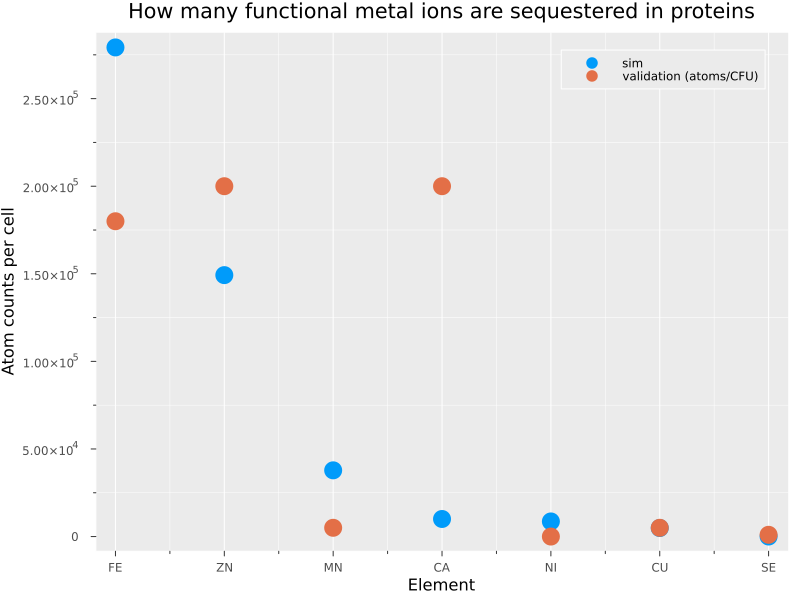

In [45]:
element_timeseries = total_counts * C * P * E

cur_elements = ["FE", "MN", "ZN", "NI", "CA", "CU", "SE"]
validation_series = [180000, 200000, 5000, 200000, 0, 5000, 1000] # FE, ZN, MN, CA, NI, CU, SE

element_idx = [element in cur_elements for element in element_names]

sorted_idxs = sortperm(element_timeseries[1,element_idx], rev=true)

current_series = element_timeseries[1,element_idx][sorted_idxs]

current_matrix = [current_series validation_series]

# element_counts = vec(sum(C_counts_elements[:, element_idx], dims=1))


plot(scatter(element_names[element_idx][sorted_idxs], 
        current_matrix, markersize=10, labels=["sim" "validation (atoms/CFU)"]), legend = true, size=[800,600],
    title="How many functional metal ions are sequestered in proteins", xlabel="Element", ylabel="Atom counts per cell",
    ygrid=false
)

In [20]:
cofactor_names

24-element Vector{String}:
 "K<SUP>+</SUP>"
 "Ni<sup>2+</sup>"
 "a [2Fe-2S] iron-sulfur cluster"
 "molybdate"
 "(<i>R</i>)-lipoate"
 "Zn<SUP>2+</SUP>"
 "Co<SUP>2+</SUP>"
 "Ca<SUP>2+</SUP>"
 "heme <i>b</i>"
 "a [3Fe-4S] iron-sulfur cluster"
 "Na<SUP>+</SUP>"
 "FMN"
 "Cu<SUP>2+</SUP>"
 "biotin"
 "Mg<SUP>2+</SUP>"
 "L-selenocysteine"
 "Fe<sup>2+</sup>"
 "a [4Fe-4S] iron-sulfur cluster"
 "Mn<SUP>2+</SUP>"
 "MoO<sub>2</sub>-molybdopterin cofactor"
 "FAD"
 "pyridoxal 5'-phosphate"
 "thiamine diphosphate"
 "Any+2"

In [21]:
element_timeseries = total_counts * C * P

cur_elements = ["FAD", "FMN", "thiamine diphosphate", "pyridoxal 5'-phosphate", "biotin", "(<i>R</i>)-lipoate"]

element_idx = [element in cur_elements for element in cofactor_names]

sorted_idxs = sortperm(element_timeseries[1,element_idx], rev=true)

plot(bar(cofactor_names[element_idx][sorted_idxs], element_timeseries[1,element_idx][sorted_idxs]), legend = false, size=[1000,600],
    title="How many functional organic cofactors are sequestered in proteins (sim)", xlabel="Cofactor", ylabel="Counts per cell")

savefig("figures/organic_counts.svg")

"/Users/cyrus/vivarium-ecoli/notebooks/cofactors/figures/organic_counts.svg"

# animation test

In [22]:
# n_steps = size(total_counts)[1]

# SRC = Any[]
# DST = Any[]
# WEIGHTS = Any[]

# for k in 1:n_steps
#     counts = vec(total_counts[k, :])
#     cur_elements = ["FE"]
#     cap_entries = 25

#     # create counts matrices
#     C_P_counts = C .* repeat(counts, 1, length(monomer_names))
#     # C_E_counts = C_P_counts * P * E
#     C_O_counts = C_P_counts * P
#     cofactor_counts = vec(sum(C_O_counts, dims=1))
#     O_E_counts =  E .* repeat(cofactor_counts, 1, length(element_names))


#     # we have to normalize the array because C is not norm-preserving. 
#     C_norm = Array{Float64}(copy(C))

#     for i in 1:size(C)[2]
#         C_norm[i, :] = C[i, :] / (sum(C[i, :]) + 0.00001)
#     end

#     C_P_norm_counts = C .* repeat(counts, 1, length(monomer_names))
#     C_W_norm_counts_cats = C_P_norm_counts * W * W2

#     # creating element indices of interest
#     element_idxs = [element in cur_elements for element in element_names]
#     element_idxs_nz = findall(vec(element_idxs))

#     # create cofactor indices of interest
#     cofactor_idxs = vec(E[:, element_idxs] .> 0)
#     cofactor_idxs_nz = findall(vec(cofactor_idxs))

#     ## cplx sorted by counts of elements
#     capped_complex_idx = sortperm(vec(sum(C_O_counts[:, cofactor_idxs], dims=2)), rev=true)[1:cap_entries]
#     capped_classes = findall(vec(sum(C_W_norm_counts_cats[capped_complex_idx, :],dims=1) .!= 0))

#     capped_C_O = C_O_counts[capped_complex_idx, cofactor_idxs]
#     capped_C_W = C_W_norm_counts_cats[capped_complex_idx, capped_classes]
#     capped_O_E = O_E_counts[cofactor_idxs, element_idxs]


#     # corrective factor multiplies a cplx by its cofactor stoichiometry, needed for classes
#     corrective_factor = sum((C * P * E)[capped_complex_idx, element_idxs], dims=2)
#     cofactor_element_corrective_factor = vec(E[cofactor_idxs, element_idxs])
#     cplx_element_norm = vec(capped_C_O * vec(E[cofactor_idxs, element_idxs]))
#     cplx_class_norm = vec(sum(capped_C_W, dims=2))

#     # create "remaining cofactors"
#     total_cofactor_counts = vec(sum(C_O_counts[:, cofactor_idxs], dims=1))
#     in_use_cofactor_counts = vec(sum(capped_C_O, dims=1))
#     remaining_cofactor_counts = vec(total_cofactor_counts - in_use_cofactor_counts)

#     # create "no class cplx", just use C_O counts
#     unclassified_cplx_idxs = vec(sum(capped_C_W, dims=2) .== 0)
#     unclassified_cplx_counts = vec(capped_C_O * cofactor_element_corrective_factor)

#     # create sizes
#     n_cplx = length(capped_complex_idx)
#     n_classes = length(capped_classes)
#     n_cofactors = length(cofactor_idxs_nz)
#     n_elements = length(cur_elements)

#     # initialize arrays
#     src = Vector{Int64}()
#     dst = Vector{Int64}()
#     weights = Vector{Int64}()

#     # create labels
#     node_labels = [element_names[element_idxs]; 
#                     cofactor_names[cofactor_idxs];
#                     protein_names[capped_complex_idx]; 
#                     pathway_names[capped_classes];
#                     ["$c, other proteins" for c ∈ cofactor_names[cofactor_idxs]];
#                     "No pathway"
#     ]

#     # create colors
#     colors = zeros(Int64, length(node_labels))

#     cofactor_colors = collect(1:(n_cofactors))
#     other_color = 0

#     colors[1] = 1
#     colors[2:(n_cofactors+1)] = cofactor_colors

#     # create sorting
#     ## sorts elements
#     ordering = Vector{Pair{Int64, Int64}}()
#     sort_cofactors = sortperm(vec(sum(capped_C_O, dims=1)) .* cofactor_element_corrective_factor, rev=true)
#     for i in 1:(n_cofactors-1)
#         push!(ordering, (n_elements + sort_cofactors[i])=> (n_elements + sort_cofactors[i+1]))
#     end
    
#     sort_cplx = sortperm(vec(sum(capped_C_O, dims=2)), rev=true)
#     for i in 1:(n_cofactors-1)
#         push!(ordering_cofactors, (n_elements + n_cofactors + sort_cplx[i])=> (n_elements + n_cofactors + sort_cplx[i+1]))
#     end


#     # order of index assignments
#     # elements, cplx, classes, remaining elements, no class label

#     # chart progress: E -> O -> C -> W
#     # E -> O 
#     for i in 1:n_elements
#         for j in 1:n_cofactors
#             if capped_O_E[j, i] != 0

#                 push!(src, i)
#                 push!(dst, n_elements + j)
#                 push!(weights, capped_O_E[j, i])

#                 # colors[n_elements + j] = colors[i]

#             end  
#         end
#     end

#     # E -> O, reverse order because im a dumbass
#     for i in 1:n_cofactors
#         for j in 1:n_cplx
#             if capped_C_O[j, i] != 0

#                 push!(src, n_elements + i)
#                 push!(dst, n_elements + n_cofactors + j)
#                 push!(weights, trunc(Int, capped_C_O[j, i] * cofactor_element_corrective_factor[i]))

#                 colors[n_elements + n_cofactors + j] = colors[n_elements + i]

#             end  
#         end
#     end

#     # # C -> W
#     for i in 1:n_cplx
#         for j in 1:n_classes
#             if capped_C_W[i, j] != 0

#                 # corrective factor multiplies by element multiplicity to maintain flow size

#                 push!(src, n_elements + n_cofactors + i)
#                 push!(dst, n_elements + n_cofactors  + n_cplx + j)
#                 push!(weights, trunc(Int64, trunc(Int, capped_C_W[i, j] * cplx_element_norm[i]/cplx_class_norm[i])))  # just corrects to sum of previous

#                 colors[n_elements + n_cofactors + n_cplx + j] = colors[n_elements + n_cofactors + i]

#             end  
#         end

#     #     if unclassified_cplx_idxs[i]
#     #         push!(src, n_elements + n_cofactors + i)
#     #         push!(dst, n_elements + n_cofactors + n_cplx + n_classes + n_elements + 1)
#     #         push!(weights, unclassified_cplx_counts[i])

#     #         colors[n_elements + n_cofactors + n_cplx + n_classes + n_elements + 1] = colors[n_elements + n_cofactors + i]
#     #     end

#     end

#     # O -> C remaining cnts
#     for i in 1:n_cofactors
#         push!(src, n_elements + i)
#         push!(dst, n_elements + n_cofactors + n_cplx + n_classes + i)
#         push!(weights, trunc(Int, remaining_cofactor_counts[i] * cofactor_element_corrective_factor[i]))
#         colors[n_elements + n_cofactors + n_cplx + n_classes + i] = colors[n_elements+i]
#     end 

#     # # C -> W remaining cplxes in 
#     for i in 1:n_cplx
#         if unclassified_cplx_idxs[i]
#             push!(src, n_elements + n_cofactors + i)
#             push!(dst, n_elements + n_cofactors + n_cplx + n_classes + n_cofactors + 1)
#             push!(weights, trunc(Int, unclassified_cplx_counts[i]))
#             colors[n_elements + n_cofactors + n_cplx + n_classes + n_cofactors + 1] = colors[i]
#         end
#     end 

#     push!(SRC, src)
#     push!(DST, dst)
#     push!(WEIGHTS,weights)
    
    
# end

In [23]:
WEIGHTS

LoadError: UndefVarError: `WEIGHTS` not defined

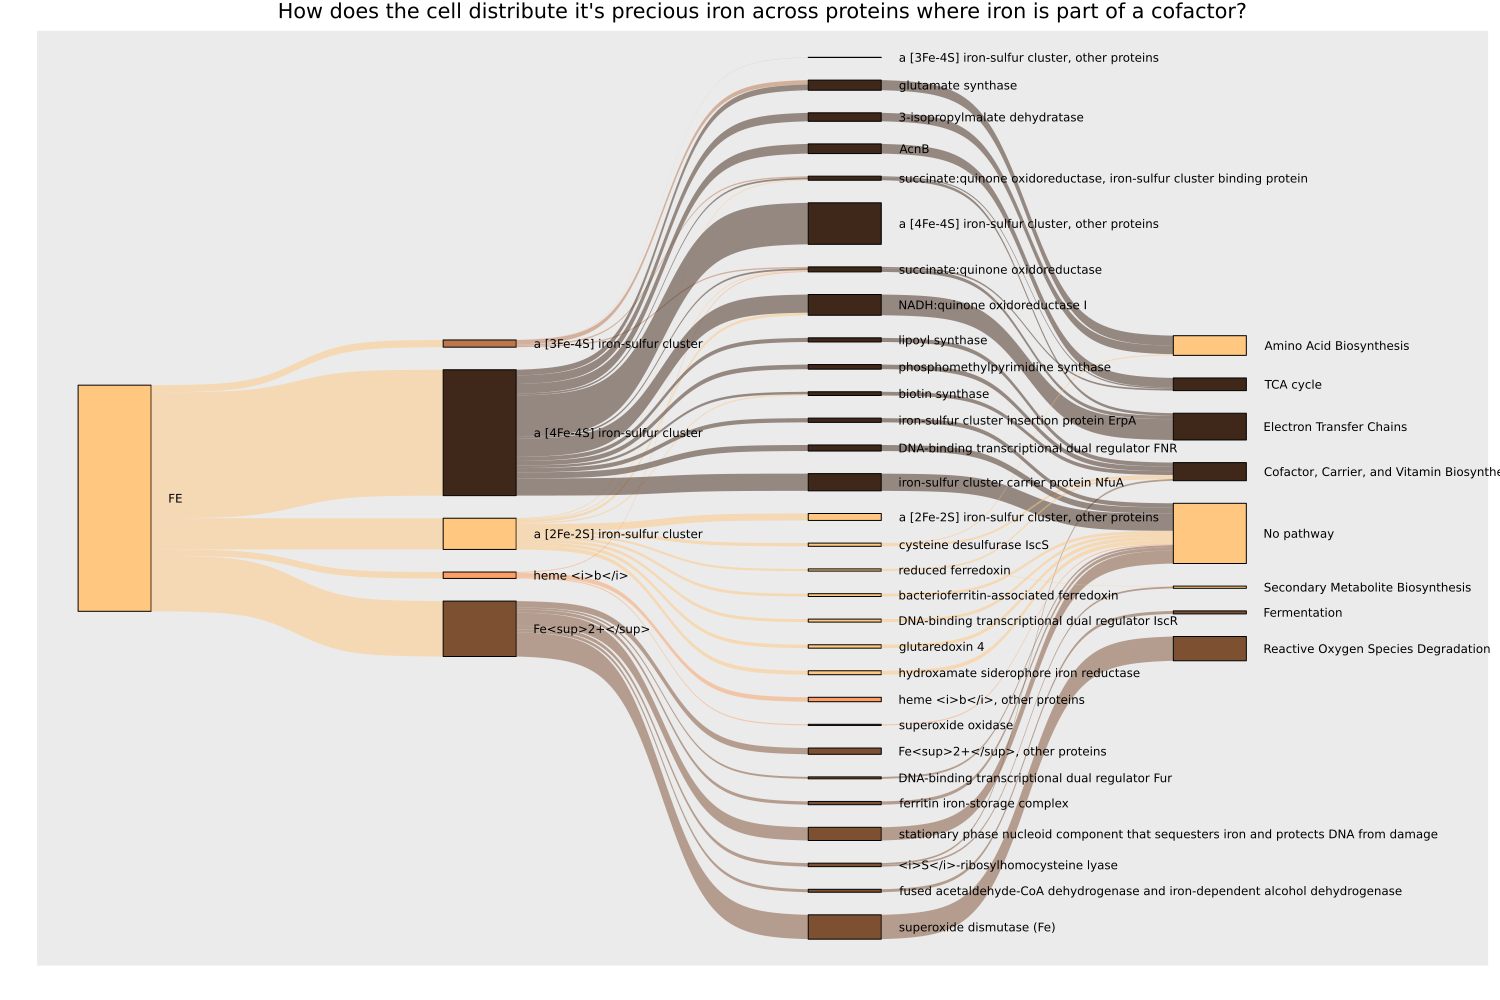# misc

In [24]:
anim = Animation()

# Define different sets of src, dst, and weights for animation frames

for i in 1:n_steps
    src = SRC[i]
    dst = DST[i]
    weights = WEIGHTS[i]

    p = sankey(src, dst, weights,
               compact = true,
               # node_labels = node_labels,
               # node_colors = cgrad(:copper, maximum(colors)+1, categorical = true, rev=true)[colors],
               edge_color = :src,
               size=(1500, 1000),
               label_position = :right,
               label_size = 8,
               force_order = ordering_cofactors,
               title="Frame $i: Iron Distribution Animation")
    
    frame(anim, p)
end

display(anim)

# Save the animation as a gif
gif(anim, "iron_cofactor_animation.gif", fps = 3)

LoadError: UndefVarError: `n_steps` not defined

In [25]:
W[4166, 578]

1.0

In [26]:
C_norm[1023, 4166] * W[4166, 578]

0.9999950000249999

In [27]:
C_W_norm_counts_cats[1023,578]

0.0

In [28]:
findfirst(isequal("REACTIVE-OXYGEN-SPECIES-DEGRADATION"), pathway_names)

In [29]:
findfirst(isequal("DETOX1-PWY"), pathway_names)

In [30]:
findfirst(isequal("CARBPSYN-CPLX"), protein_names)

139

In [31]:
sum(C_norm[139,:])

0.9999975000062501

In [32]:
C[:, i]

LoadError: UndefVarError: `i` not defined

In [33]:
C_norm[:, i] = C[:, i] / sum(C[:, i])

LoadError: UndefVarError: `i` not defined